In [1]:
import os
import sys
import time
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Paths
THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR  # unmerge/count
REPO_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..', '..'))  # PracticeTagging

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import importlib
from model import CountTransformer  # noqa: E402
 
importlib.reload(tool)  # noqa: E402

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Experiment output
RUN_NAME = 'CountOnly_N_off'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(REPO_DIR, 'test.h5'),
    'n_jets': 50000,
    'max_particles': 200,
    'hlt_effects': {
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 1.5,
        'merge_enabled': True,
        'merge_radius': 0.01,
        'efficiency_loss': 0.03,
    },
    'count_model': {
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 4,
        'ff_dim': 512,
        'dropout': 0.1,
        # 'softplus_beta': 0.3,
    },
    'training': {
        'batch_size': 512,
        'epochs': 60,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 8,
        'huber_delta': 1.0,
    },
    'target': {
        # 'deltaN' = N_off - N_hlt (recommended)
        # 'N_off'  = offline token count (after offline threshold)
        # 'kind': 'deltaN',
        'kind': 'N_off',
        'clip_max': None,  # e.g. 60 if you want to clip extreme tails
    },
    'io': {
        'run_name': RUN_NAME,
        'out_dir': OUT_DIR,
        'fig_dir': FIG_DIR,
        'ckpt_dir': CKPT_DIR,
        'config_path': os.path.join(OUT_DIR, 'config.json'),
        # If set to an existing file path, training will be skipped and weights reloaded.
        'load_count_model': None,
    },
}

tool.save_config(CONFIG, CONFIG['io']['config_path'])
print('Data path:', CONFIG['data_path'])
print('Run dir:', CONFIG['io']['out_dir'])

Device: cuda
Data path: d:\PracticeTagging\test.h5
Run dir: d:\PracticeTagging\unmerge\count_test_jetlevel\runs\CountOnly_N_off


In [2]:
# Load data
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)  # [N,S,4]
masks_raw = pt > 0

print('Raw:', constituents_raw.shape, 'mask:', masks_raw.shape)
print('weights:', weights.shape, 'mean=', float(weights.mean()))

Raw: (50000, 200, 4) mask: (50000, 200)
weights: (50000,) mean= 1.0007245540618896


In [3]:
# HLT simulation + offline threshold + 7D features (keep consistent with `unmerge/unmerge.ipynb`)
constituents_hlt, masks_hlt = tool.apply_hlt_effects(constituents_raw, masks_raw, CONFIG, seed=seed)

pt_thr_off = float(CONFIG['hlt_effects']['pt_threshold_offline'])
masks_off = masks_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
constituents_off = constituents_raw.copy()
constituents_off[~masks_off] = 0

features_off = tool.compute_features(constituents_off, masks_off)
features_hlt = tool.compute_features(constituents_hlt, masks_hlt)
print('Features:', features_off.shape, features_hlt.shape)

# Split (note: count task doesn't need label stratification)
idx = np.arange(features_hlt.shape[0])
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=seed)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=seed)
print(f"Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}")

# Standardize using OFFLINE TRAIN stats
feat_means_off, feat_stds_off = tool.get_stats(features_off, masks_off, train_idx)
features_off_std = tool.standardize(features_off, masks_off, feat_means_off, feat_stds_off, clip=10.0)
features_hlt_std = tool.standardize(features_hlt, masks_hlt, feat_means_off, feat_stds_off, clip=10.0)
print('Standardization done.')

Features: (50000, 200, 7) (50000, 200, 7)
Split: train=35,000 val=7,500 test=7,500
Standardization done.


Plotting feature distributions on TRAIN split (sampled)...
Saved figure: d:\PracticeTagging\unmerge\count_test_jetlevel\runs\CountOnly_N_off\figs\feat_dists_train.png


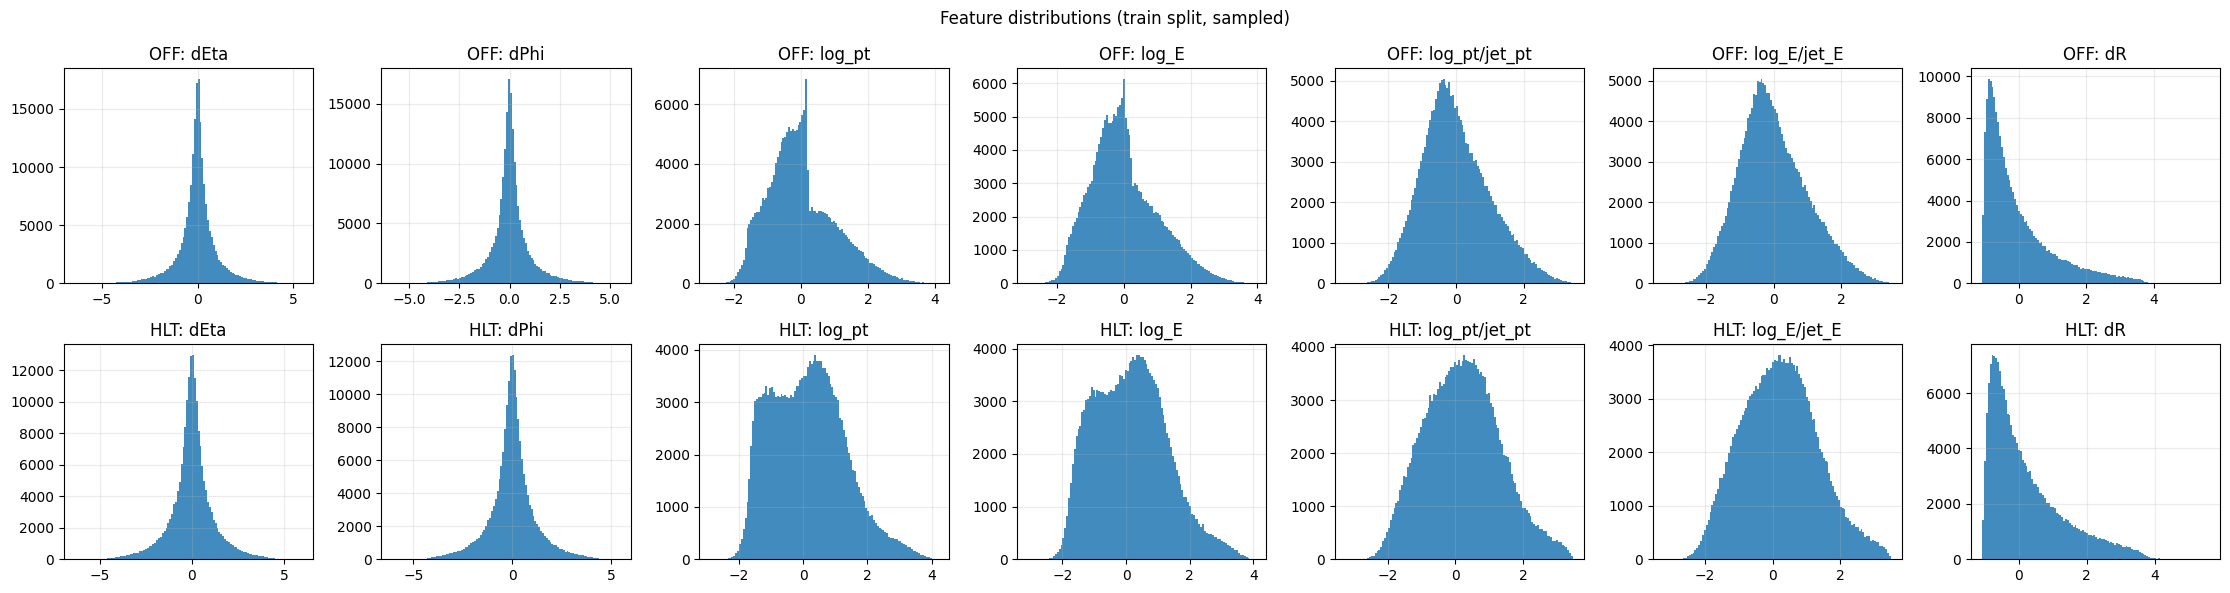

In [4]:
# (Optional) Feature distribution visualization
feat_fig_path = os.path.join(CONFIG['io']['fig_dir'], 'feat_dists_train.png')
print('Plotting feature distributions on TRAIN split (sampled)...')
tool.plot_feat_dists(
    features_off_std,
    masks_off,
    features_hlt_std,
    masks_hlt,
    jet_idx=train_idx,
    title='Feature distributions (train split, sampled)',
    bins=120,
    max_vals=200_000,
    clip=(-10, 10),
    seed=seed,
    save_path=feat_fig_path,
    dpi=160,
)

Target: N_off
N_off: mean= 55.84931945800781 p99= 144.0
N_hlt: mean= 32.881500244140625 p99= 91.0
y: mean= 55.84931945800781 max= 200.0 p99= 144.0
Saved figure: d:\PracticeTagging\unmerge\count_test_jetlevel\runs\CountOnly_N_off\figs\target_N_off.png


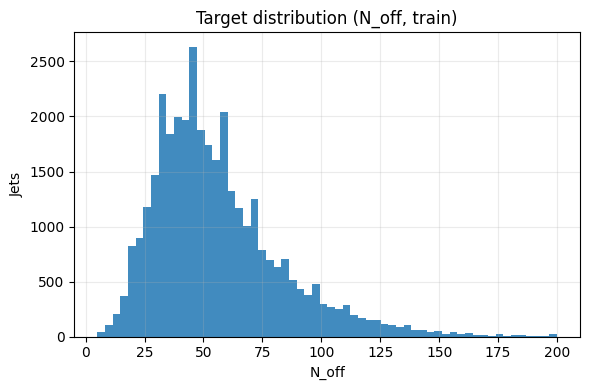

In [5]:
# Build jet-level count target
t_kind = str(CONFIG['target']['kind'])
clip_max = CONFIG['target'].get('clip_max', None)

N_off = masks_off.sum(axis=1).astype(np.float32)
N_hlt = masks_hlt.sum(axis=1).astype(np.float32)

y_all = None
if t_kind.lower() == 'n_off':
    y_all = N_off
elif t_kind.lower() == 'deltan':
    y_all = N_off - N_hlt
else:
    raise ValueError(f"Unknown target.kind: {t_kind}")

y_all = np.clip(y_all, 0.0, 1e9)
if clip_max is not None:
    y_all = np.clip(y_all, 0.0, float(clip_max))

print('Target:', t_kind)
print('N_off: mean=', float(N_off.mean()), 'p99=', float(np.percentile(N_off, 99)))
print('N_hlt: mean=', float(N_hlt.mean()), 'p99=', float(np.percentile(N_hlt, 99)))
print('y: mean=', float(y_all.mean()), 'max=', float(y_all.max()), 'p99=', float(np.percentile(y_all, 99)))

# Quick visualization (saved)
count_target_fig = os.path.join(CONFIG['io']['fig_dir'], f"target_{t_kind}.png")
plt.figure(figsize=(6, 4))
plt.hist(y_all[train_idx], bins=60, alpha=0.85)
plt.xlabel(t_kind)
plt.ylabel('Jets')
plt.title(f"Target distribution ({t_kind}, train)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(count_target_fig, dpi=160, bbox_inches='tight')
print('Saved figure:', count_target_fig)
plt.show()

In [6]:
# DataLoaders
BS = int(CONFIG['training']['batch_size'])

train_ds = tool.JetCountDataset(features_hlt_std[train_idx], masks_hlt[train_idx], y_all[train_idx], weights=weights[train_idx])
val_ds = tool.JetCountDataset(features_hlt_std[val_idx], masks_hlt[val_idx], y_all[val_idx], weights=weights[val_idx])
test_ds = tool.JetCountDataset(features_hlt_std[test_idx], masks_hlt[test_idx], y_all[test_idx], weights=weights[test_idx])

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BS)
test_loader = DataLoader(test_ds, batch_size=BS)

print('Loaders ready, BS=', BS)

Loaders ready, BS= 512


In [7]:
# Train / Reload Count-only model
io = CONFIG['io']
count_ckpt = os.path.join(io['ckpt_dir'], 'count_model.pt')
io['count_ckpt'] = count_ckpt
tool.save_config(CONFIG, io['config_path'])

epochs = int(CONFIG['training']['epochs'])
lr = float(CONFIG['training']['lr'])
wd = float(CONFIG['training']['weight_decay'])
warm = int(CONFIG['training']['warmup_epochs'])
pat = int(CONFIG['training']['patience'])
huber_delta = float(CONFIG['training'].get('huber_delta', 1.0))

# Avoid softplus saturation at ~0 by:
# - using smaller softplus_beta (more linear for negative raw)
# - initializing last bias to a reasonable prior (train mean)
softplus_beta = float(CONFIG['count_model'].get('softplus_beta', 1))
print('Softplus beta:', softplus_beta)
init_bias = float(np.mean(y_all[train_idx]))

model = CountTransformer(**CONFIG['count_model'], softplus_beta=softplus_beta, init_bias=init_bias).to(device)
load_path = io.get('load_count_model')

if load_path:
    print(f"Loading count model checkpoint: {load_path}")
    tool.load_checkpoint(model, load_path, map_location=device)
else:
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sch = tool.get_scheduler(opt, warm, epochs)

    best_mae = 1e9
    best_state = None
    no_imp = 0

    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr_loss = tool.train_count_epoch(model, train_loader, opt, device, huber_delta=huber_delta)
        val_mae, val_rmse, val_bias, _, _ = tool.eval_count(model, val_loader, device)
        sch.step()

        improved = (val_mae < best_mae - 1e-4)
        if improved:
            best_mae = val_mae
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        if ep == 1 or ep % 5 == 0:
            dt = time.time() - t0
            print(
                f"[Count] ep={ep:03d} tr_loss={tr_loss:.4f} val_mae={val_mae:.4f} val_rmse={val_rmse:.4f} bias={val_bias:.4f} best_mae={best_mae:.4f} no_imp={no_imp} time={dt:.1f}s"
            )

        if no_imp >= pat:
            print('[Count] Early stopping')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    tool.save_checkpoint(
        model,
        count_ckpt,
        extra={'best_val_mae': float(best_mae), 'init_bias': init_bias, 'softplus_beta': softplus_beta},
    )
    print(f"Saved count model checkpoint: {count_ckpt}")

# Test evaluation
mae_t, rmse_t, bias_t, pred_t, true_t = tool.eval_count(model, test_loader, device)
print(f"Test: MAE={mae_t:.4f} RMSE={rmse_t:.4f} Bias={bias_t:.4f}")

# Quick diagnostic: how many predictions are near 0?
frac_lt_0p5 = float((pred_t < 0.5).mean())
frac_lt_1 = float((pred_t < 1.0).mean())
print(f"Pred near zero: frac(pred<0.5)={frac_lt_0p5:.3f} frac(pred<1.0)={frac_lt_1:.3f}")

n_hlt_test = masks_hlt[test_idx].sum(axis=1)
print('Test n_hlt: p1/p50/p99 =', np.percentile(n_hlt_test, [1, 50, 99]).astype(int))

Softplus beta: 1.0


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Count] ep=001 tr_loss=17.9565 val_mae=17.1504 val_rmse=22.0724 bias=2.5110 best_mae=17.1504 no_imp=0 time=38.4s
[Count] ep=005 tr_loss=8.9185 val_mae=11.5002 val_rmse=14.3959 bias=6.4045 best_mae=11.5002 no_imp=0 time=179.5s
[Count] ep=010 tr_loss=4.8964 val_mae=16.7464 val_rmse=18.9468 bias=16.7112 best_mae=7.0525 no_imp=2 time=358.4s
[Count] ep=015 tr_loss=4.4875 val_mae=19.1205 val_rmse=20.7133 bias=19.1111 best_mae=7.0525 no_imp=7 time=535.2s
[Count] Early stopping
Saved count model checkpoint: d:\PracticeTagging\unmerge\count_test_jetlevel\runs\CountOnly_N_off\ckpts\count_model.pt
Test: MAE=7.0324 RMSE=8.6647 Bias=4.9372
Pred near zero: frac(pred<0.5)=0.000 frac(pred<1.0)=0.000
Test n_hlt: p1/p50/p99 = [ 6 29 91]


Saved figure: d:\PracticeTagging\unmerge\count_test_jetlevel\runs\CountOnly_N_off\figs\count_pred_test.png


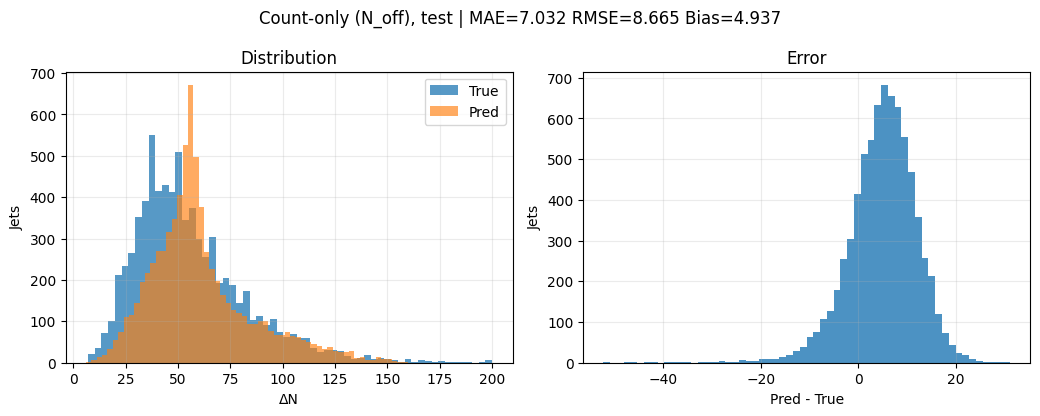

Saved figure: d:\PracticeTagging\unmerge\count_test_jetlevel\runs\CountOnly_N_off\figs\count_scatter_test.png


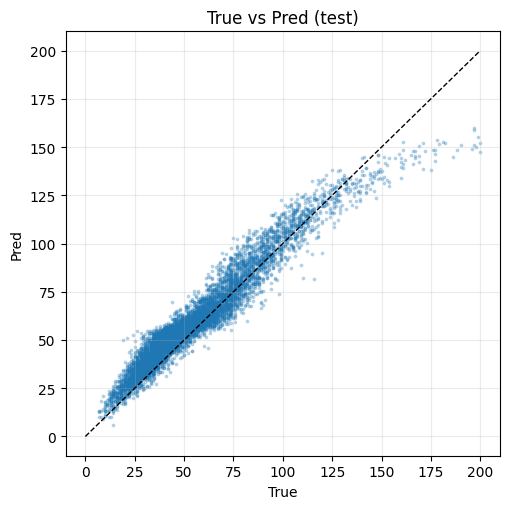

In [8]:
# Save plots for prediction quality
pred_fig = os.path.join(CONFIG['io']['fig_dir'], 'count_pred_test.png')
tool.plot_count_predictions(
    pred_t,
    true_t,
    title=f"Count-only ({CONFIG['target']['kind']}), test | MAE={mae_t:.3f} RMSE={rmse_t:.3f} Bias={bias_t:.3f}",
    bins=60,
    save_path=pred_fig,
    dpi=160,
)

# Scatter plot (saved)
scatter_fig = os.path.join(CONFIG['io']['fig_dir'], 'count_scatter_test.png')
plt.figure(figsize=(5.2, 5.2))
plt.scatter(true_t, pred_t, s=3, alpha=0.25)
mx = float(max(true_t.max(), pred_t.max()))
plt.plot([0, mx], [0, mx], 'k--', lw=1)
plt.xlabel('True')
plt.ylabel('Pred')
plt.title('True vs Pred (test)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(scatter_fig, dpi=160, bbox_inches='tight')
print('Saved figure:', scatter_fig)
plt.show()